# Experimental notebook — Understanding dimensional collapse in contrastive learning

This notebook reproduces, on **small synthetic experiments**, the main phenomena discussed in:

- **Paper B:** *Understanding Dimensional Collapse in Contrastive Self-Supervised Learning* (ICLR 2022)
- with a final bridge to **DirectCLR**, the solution proposed in that paper.

It is inspired by the structure of the CLOP notebook, but the objective here is different:

1. **show the pathology**: contrastive learning can avoid trivial rank-1 collapse while still suffering from **dimensional collapse**;
2. **separate the two mechanisms** described in the paper:
   - collapse due to **strong augmentation**;
   - collapse due to **implicit regularization** in deeper models;
3. **show the role of the projector** and why **DirectCLR** can mitigate representation collapse.

All experiments are intentionally lightweight and CPU-friendly.

## Roadmap

We will run four experiments:

1. **Strong augmentation in a linear encoder**  
   Increasing augmentation strength makes some singular values of the encoder and of the embedding covariance shrink toward zero.

2. **Implicit regularization in deep linear encoders**  
   Even with weak augmentation, deeper linear contrastive models tend toward low-rank solutions.

3. **Layer alignment in a 2-layer linear encoder**  
   The paper predicts that adjacent layers align during training.

4. **No projector vs linear projector vs DirectCLR-style subvector loss**  
   We compare representation spectra and downstream accuracy on a synthetic labeled task.

> The goal is not to reproduce ImageNet numbers, but to reproduce the **geometry and dynamics** highlighted by the paper.

In [2]:
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

torch.manual_seed(7)
np.random.seed(7)
random.seed(7)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## Utilities

In [4]:
def set_seed(seed: int = 7):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

def off_diagonal_mean_abs(M: torch.Tensor) -> float:
    M = M.detach().cpu()
    n = M.shape[0]
    return (M - torch.diag(torch.diag(M))).abs().sum().item() / (n * (n - 1))

def covariance_spectrum(Z: torch.Tensor) -> torch.Tensor:
    Z = Z - Z.mean(dim=0, keepdim=True)
    C = (Z.T @ Z) / max(1, Z.shape[0] - 1)
    return torch.linalg.svdvals(C).detach().cpu()

def effective_rank_from_svals(svals: torch.Tensor, eps: float = 1e-12) -> float:
    p = svals / (svals.sum() + eps)
    entropy = -(p * (p + eps).log()).sum().item()
    return float(np.exp(entropy))

def numerical_rank(svals: torch.Tensor, tol_ratio: float = 1e-3) -> int:
    smax = float(svals.max().item())
    return int((svals >= tol_ratio * smax).sum().item())

def plot_spectra(spectra: Dict[str, torch.Tensor], title: str, logy: bool = True):
    plt.figure(figsize=(7, 4))
    for name, svals in spectra.items():
        y = svals.numpy()
        x = np.arange(1, len(y) + 1)
        plt.plot(x, y, marker="o", linewidth=1.5, label=name)
    if logy:
        plt.yscale("log")
    plt.xlabel("Rank index")
    plt.ylabel("Singular value")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def two_view_gaussian_batch(batch_size: int, d: int, aug_std: float, anisotropic: bool = False):
    x = torch.randn(batch_size, d, device=device)
    if anisotropic:
        noise = torch.randn(batch_size, d, device=device)
        # stronger augmentation on the second half of dimensions
        scale = torch.ones(d, device=device)
        scale[d//2:] = aug_std
        scale[:d//2] = max(1e-8, aug_std * 0.1)
        eps1 = noise * scale
        eps2 = torch.randn(batch_size, d, device=device) * scale
    else:
        eps1 = torch.randn(batch_size, d, device=device) * aug_std
        eps2 = torch.randn(batch_size, d, device=device) * aug_std
    return x + eps1, x + eps2

def info_nce_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.2):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    z = torch.cat([z1, z2], dim=0)
    sim = (z @ z.T) / temperature

    n = z1.shape[0]
    mask = torch.eye(2 * n, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -1e9)

    targets = torch.arange(n, device=z.device)
    targets = torch.cat([targets + n, targets], dim=0)

    return F.cross_entropy(sim, targets)

def build_prototypes(num_classes: int, dim: int) -> torch.Tensor:
    A = torch.randn(dim, dim)
    Q, _ = torch.linalg.qr(A)
    return F.normalize(Q[:, :num_classes].T, dim=1)

def clop_penalty(z_labeled: torch.Tensor, y_labeled: torch.Tensor, prototypes: torch.Tensor):
    z_labeled = F.normalize(z_labeled, dim=1)
    p = prototypes[y_labeled]
    p = F.normalize(p, dim=1)
    return (1 - (z_labeled * p).sum(dim=1)).mean()

def make_synthetic_classification(
    n_per_class: int = 180,
    num_classes: int = 6,
    input_dim: int = 20,
    class_spread: float = 0.55,
    noise_std: float = 0.25,
):
    centers = torch.randn(num_classes, input_dim)
    centers = F.normalize(centers, dim=1) * class_spread * math.sqrt(input_dim)

    xs, ys = [], []
    for c in range(num_classes):
        x = centers[c] + noise_std * torch.randn(n_per_class, input_dim)
        y = torch.full((n_per_class,), c, dtype=torch.long)
        xs.append(x)
        ys.append(y)
    X = torch.cat(xs, dim=0)
    y = torch.cat(ys, dim=0)
    return X, y

## Experiment 1 — strong augmentation can create dimensional collapse

Paper B shows that in a linear setting, when the covariance introduced by augmentation dominates the covariance of the data along some directions, the encoder develops vanishing singular values and the embedding covariance becomes low-rank.

We simulate this with a **single linear encoder** trained with InfoNCE on Gaussian data. We vary augmentation strength and inspect:

- singular values of the encoder matrix;
- singular values of the embedding covariance;
- effective rank.

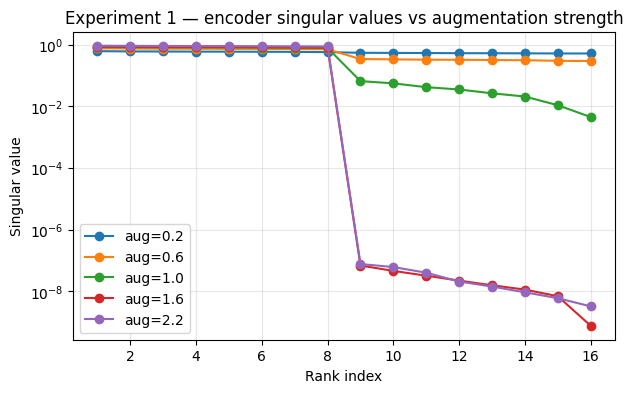

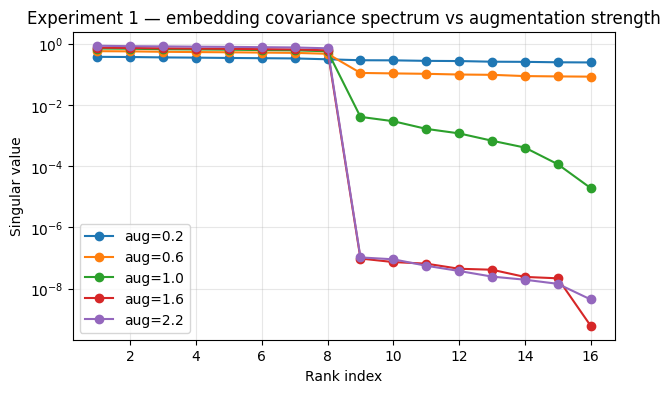

aug=0.2  | weight_rank=16 | embed_rank=16 | embed_effective_rank=15.84
aug=0.6  | weight_rank=16 | embed_rank=16 | embed_effective_rank=12.28
aug=1.0  | weight_rank=16 | embed_rank=12 | embed_effective_rank=8.10
aug=1.6  | weight_rank= 8 | embed_rank= 8 | embed_effective_rank=7.99
aug=2.2  | weight_rank= 8 | embed_rank= 8 | embed_effective_rank=7.99


In [5]:
class LinearEncoder(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.W = nn.Linear(d, d, bias=False)

    def forward(self, x):
        return self.W(x)

def train_linear_encoder(
    d: int = 16,
    aug_std: float = 0.2,
    epochs: int = 300,
    batch_size: int = 256,
    lr: float = 1e-1,
    temperature: float = 0.2,
    anisotropic: bool = True,
):
    set_seed(7)
    model = LinearEncoder(d).to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr)

    losses = []
    for _ in range(epochs):
        x1, x2 = two_view_gaussian_batch(batch_size, d, aug_std=aug_std, anisotropic=anisotropic)
        z1 = model(x1)
        z2 = model(x2)
        loss = info_nce_loss(z1, z2, temperature=temperature)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    with torch.no_grad():
        W = model.W.weight.detach()
        w_svals = torch.linalg.svdvals(W).cpu()

        X_eval = torch.randn(4000, d, device=device)
        Z = model(X_eval)
        z_svals = covariance_spectrum(Z)

    return {
        "model": model,
        "losses": losses,
        "weight_svals": w_svals,
        "embed_svals": z_svals,
        "weight_rank": numerical_rank(w_svals),
        "embed_rank": numerical_rank(z_svals),
        "embed_erank": effective_rank_from_svals(z_svals),
    }

strengths = [0.2, 0.6, 1.0, 1.6, 2.2]
results_aug = {}
for s in strengths:
    results_aug[f"aug={s}"] = train_linear_encoder(aug_std=s)

plot_spectra(
    {k: v["weight_svals"] for k, v in results_aug.items()},
    "Experiment 1 — encoder singular values vs augmentation strength"
)

plot_spectra(
    {k: v["embed_svals"] for k, v in results_aug.items()},
    "Experiment 1 — embedding covariance spectrum vs augmentation strength"
)

for k, v in results_aug.items():
    print(
        f"{k:8s} | weight_rank={v['weight_rank']:2d} | embed_rank={v['embed_rank']:2d} | "
        f"embed_effective_rank={v['embed_erank']:.2f}"
    )

### Comment

The exact threshold depends on initialization and hyperparameters, but the expected trend is:

- weak augmentation → fuller spectrum;
- strong augmentation → more singular values close to zero.

This mirrors the first mechanism of Paper B.

## Experiment 2 — implicit regularization in deeper linear networks

Paper B argues that even when augmentation is not strong enough to explain collapse, **depth itself** can induce low-rank behavior through implicit regularization.

We now compare linear encoders with different depths, all trained with weak augmentation.

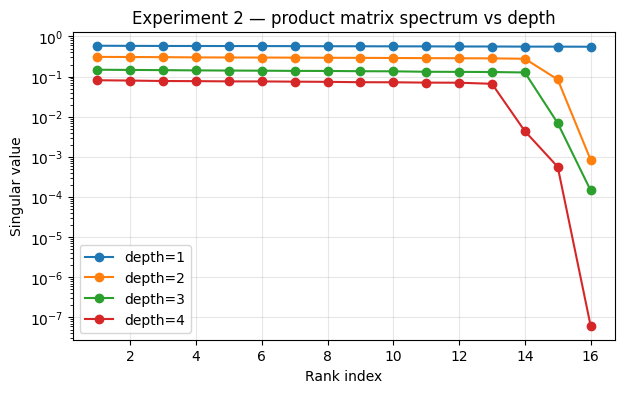

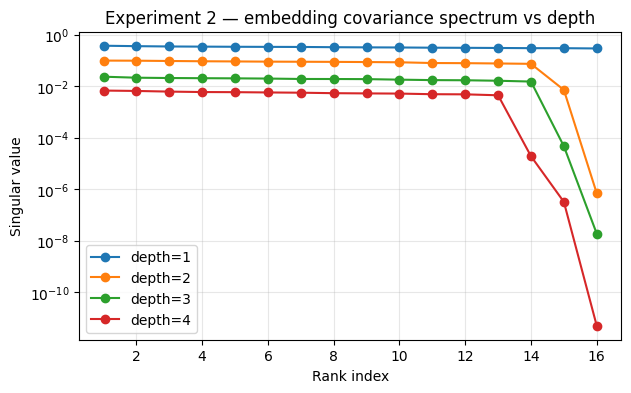

depth=1 | product_rank=16 | embed_rank=16 | embed_effective_rank=15.96
depth=2 | product_rank=16 | embed_rank=15 | embed_effective_rank=14.24
depth=3 | product_rank=15 | embed_rank=15 | embed_effective_rank=13.93
depth=4 | product_rank=15 | embed_rank=14 | embed_effective_rank=12.93


In [8]:
class DeepLinearEncoder(nn.Module):
    def __init__(self, d: int, depth: int):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(d, d, bias=False) for _ in range(depth)])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def product_matrix(self):
        W = self.layers[-1].weight
        for layer in reversed(self.layers[:-1]):
            W = W @ layer.weight
        return W.detach()

def train_deep_linear(
    d: int = 16,
    depth: int = 2,
    aug_std: float = 0.15,
    epochs: int = 350,
    batch_size: int = 256,
    lr: float = 0.05,
    temperature: float = 0.2,
):
    set_seed(7 + depth)
    model = DeepLinearEncoder(d, depth).to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr)

    losses = []
    for _ in range(epochs):
        x1, x2 = two_view_gaussian_batch(batch_size, d, aug_std=aug_std, anisotropic=False)
        z1 = model(x1)
        z2 = model(x2)
        loss = info_nce_loss(z1, z2, temperature=temperature)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    with torch.no_grad():
        Wprod = model.product_matrix().cpu()
        w_svals = torch.linalg.svdvals(Wprod)

        X_eval = torch.randn(5000, d, device=device)
        Z = model(X_eval)
        z_svals = covariance_spectrum(Z)

    return {
        "model": model,
        "losses": losses,
        "product_svals": w_svals,
        "embed_svals": z_svals,
        "product_rank": numerical_rank(w_svals),
        "embed_rank": numerical_rank(z_svals),
        "embed_erank": effective_rank_from_svals(z_svals),
    }

depths = [1, 2, 3, 4]
results_depth = {}
for depth in depths:
    results_depth[f"depth={depth}"] = train_deep_linear(depth=depth)

plot_spectra(
    {k: v["product_svals"] for k, v in results_depth.items()},
    "Experiment 2 — product matrix spectrum vs depth"
)

plot_spectra(
    {k: v["embed_svals"] for k, v in results_depth.items()},
    "Experiment 2 — embedding covariance spectrum vs depth"
)

for k, v in results_depth.items():
    print(
        f"{k:4s} | product_rank={v['product_rank']:2d} | embed_rank={v['embed_rank']:2d} | "
        f"embed_effective_rank={v['embed_erank']:.2f}"
    )

### Comment

The qualitative prediction is:

- depth 1: much less collapse;
- depth 2–4: progressively stronger rank deficiency.

That is the second mechanism emphasized in Paper B: **implicit regularization in multi-layer models**.

## Experiment 3 — alignment of adjacent layers

In the 2-layer linear analysis of Paper B, the right singular vectors of the second layer align with the left singular vectors of the first layer.

We track the alignment matrix:

$$
A = V_2^T U_1
$$

and monitor how close it gets to the identity.

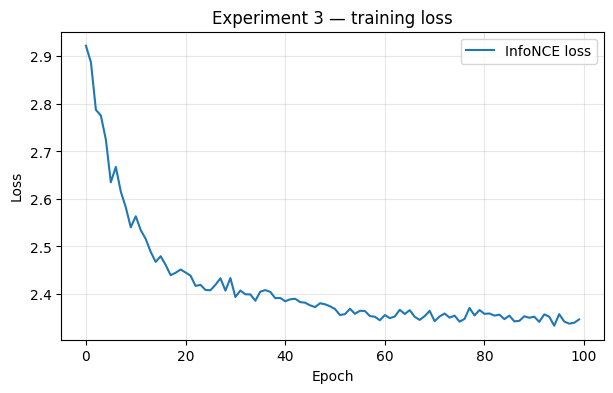

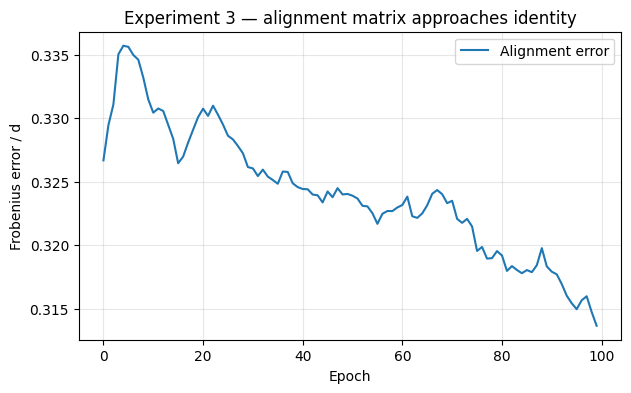

Initial/Final alignment error: 0.32667797803878784 -> 0.3136533200740814
Mid alignment error: 0.3136533200740814


In [13]:
def alignment_error_2layer(model: DeepLinearEncoder) -> float:
    assert len(model.layers) == 2
    W1 = model.layers[0].weight.detach().cpu()
    W2 = model.layers[1].weight.detach().cpu()

    U1, _, V1h = torch.linalg.svd(W1)
    U2, _, V2h = torch.linalg.svd(W2)
    V2 = V2h.T
    A = V2.T @ U1
    I = torch.eye(A.shape[0])
    return torch.norm(A.abs() - I, p="fro").item() / A.shape[0]

def train_2layer_with_alignment_trace(
    d: int = 16,
    aug_std: float = 0.15,
    epochs: int = 100,
    batch_size: int = 256,
    lr: float = 0.05,
):
    set_seed(19)
    model = DeepLinearEncoder(d, depth=2).to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr)

    errors = []
    losses = []
    for _ in range(epochs):
        x1, x2 = two_view_gaussian_batch(batch_size, d, aug_std=aug_std, anisotropic=False)
        z1 = model(x1)
        z2 = model(x2)
        loss = info_nce_loss(z1, z2, temperature=0.2)
        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())
        errors.append(alignment_error_2layer(model))

    return model, losses, errors

model2, losses2, align_errors = train_2layer_with_alignment_trace()

plt.figure(figsize=(7, 4))
plt.plot(losses2, label="InfoNCE loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 3 — training loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(align_errors, label="Alignment error")
plt.xlabel("Epoch")
plt.ylabel("Frobenius error / d")
plt.title("Experiment 3 — alignment matrix approaches identity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Initial/Final alignment error:", align_errors[0], "->", align_errors[-1])
print("Mid alignment error:", align_errors[99])

A decreasing alignment error supports the alignment story from the paper:
adjacent layers organize so that their singular directions match, which reinforces low-rank behavior in the product.

## Why does the alignment error vary only slightly?

In our two-layer experiment, the alignment error often decreases only modestly, sometimes by only a few $10^{-2}$. This does **not** necessarily contradict the theorem, and several reasons explain this behavior.

### 1. The optimization is noisy because we use mini-batch SGD

The theorem is stated in an asymptotic setting and is most naturally connected to a smooth gradient-flow dynamics. In our experiment, we use **mini-batch SGD**, so each update is computed from a random batch rather than from the full population objective. As a result, the dynamics are noisy, and the alignment measure can oscillate instead of decreasing monotonically.

### 2. We are far from the asymptotic regime

The theorem states that
$$
A = V_2^\top U_1 \to I
$$
under several assumptions and in the long-time limit. In practice, training for a finite number of epochs does not guarantee that we are close to that asymptotic regime.

### 3. The matrices may already look partially aligned at initialization

For randomly initialized linear layers, the singular vectors are themselves random orthonormal bases. Since
$$
A = V_2^\top U_1
$$
is the product of two orthogonal matrices, it is again an orthogonal matrix. This means that even at initialization, the matrix $A$ already has structured orthonormal columns and rows. Therefore, the alignment error is often **not extremely large at the beginning**, which reduces the room for visible improvement.

### 4. The scalar alignment error is only a coarse summary

Our metric is based on the Frobenius distance between $|A|$ and the identity:
$$
\frac{\|\,|A| - I\|_F}{d}.
$$
This is useful, but it compresses the whole alignment matrix into a single number. Small changes in the structure of $A$ may not produce a large change in this scalar error. In particular, if some singular values are close to each other, the corresponding singular vectors may be unstable or only identifiable up to rotations inside a subspace.

### 5. Distinct singular values may not hold well in practice

The theorem assumes that the limiting matrices have **distinct singular values**. When several singular values are close or degenerate, the corresponding singular vectors are not uniquely defined, and perfect convergence to the identity is no longer the most realistic visual signature. In practice, one may observe a more block-like structure rather than a perfectly diagonal one.

---

## Why can alignment be problematic?

The alignment phenomenon is important because it helps explain why deep linear contrastive models can develop **dimensional collapse** even when augmentation is not extremely strong.

Consider the two-layer model
$$
z = W_2 W_1 x
$$
with singular value decompositions
$$
W_1 = U_1 S_1 V_1^\top, \qquad
W_2 = U_2 S_2 V_2^\top.
$$

Then
$$
W_2 W_1
=
U_2 S_2 \underbrace{V_2^\top U_1}_{A} S_1 V_1^\top.
$$

If alignment occurs, then
$$
A = V_2^\top U_1 \approx I,
$$
so the product simplifies to
$$
W_2 W_1 \approx U_2 (S_2 S_1) V_1^\top.
$$

This means that the singular values of the global mapping become approximately the **products** of the singular values of the two layers:
$$
\sigma_i(W_2 W_1) \approx \sigma_i(W_2)\sigma_i(W_1).
$$

This is exactly where the problem appears:

- directions that are already slightly stronger become even stronger,
- directions that are slightly weaker become even weaker,
- repeated multiplication amplifies these differences.

As a consequence, some directions dominate while others are progressively suppressed, so the product matrix becomes effectively **low-rank**. Once this happens, the covariance of the learned embeddings also becomes low-rank, which is precisely the signature of **dimensional collapse**.

In short:

1. alignment makes adjacent layers act on the **same singular directions**,
2. their singular values then **multiply** along those directions,
3. this amplifies anisotropy,
4. and eventually produces a collapse onto a lower-dimensional subspace.

For this reason, alignment is not just a geometric curiosity: it is one of the mechanisms that can drive collapse in deep linear contrastive models.

## Experiment 4 — projector, representation collapse, and DirectCLR-style fix

The paper reports that:

- **without projector**, the **representation space** collapses more severely;
- a **projector** helps protect the representation space;
- **DirectCLR** avoids a trainable projector by applying the contrastive loss only to a fixed subvector of the representation.

We now compare three toy models on a synthetic labeled dataset:

1. **No projector**
2. **Trainable linear projector**
3. **DirectCLR-style subvector loss**

After self-supervised training, we evaluate:

- representation covariance spectrum;
- effective rank;
- a simple **kNN accuracy** on labels that were *not* used during self-supervised training.

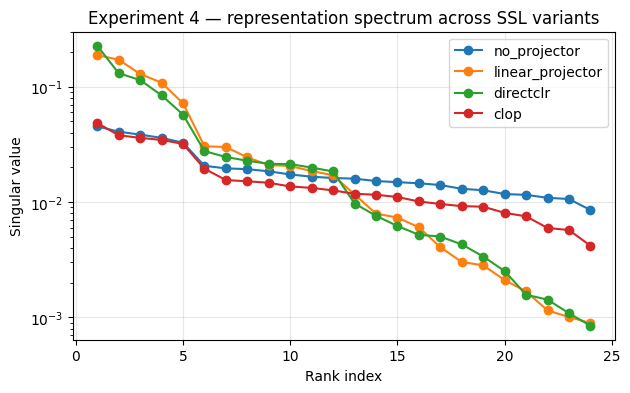

no_projector     | acc=100.00% | rep_rank=24 | rep_effective_rank=21.32
linear_projector | acc=100.00% | rep_rank=24 | rep_effective_rank=10.42
directclr        | acc=100.00% | rep_rank=24 | rep_effective_rank=10.31
clop             | acc=99.77% | rep_rank=24 | rep_effective_rank=19.39


In [6]:
class EncoderMLP(nn.Module):
    def __init__(self, input_dim: int, rep_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, rep_dim),
        )

    def forward(self, x):
        return self.net(x)

class SSLModel(nn.Module):
    def __init__(self, input_dim: int, rep_dim: int, proj_dim: int = None):
        super().__init__()
        self.encoder = EncoderMLP(input_dim, rep_dim)
        self.projector = None if proj_dim is None else nn.Linear(rep_dim, proj_dim, bias=False)

    def representation(self, x):
        return self.encoder(x)

    def embedding(self, x):
        r = self.representation(x)
        if self.projector is None:
            return r
        return self.projector(r)

def augment_tabular(x: torch.Tensor, noise_std: float = 0.2):
    return x + noise_std * torch.randn_like(x)

def train_ssl_variant(
    variant: str,
    X: torch.Tensor,
    y: torch.Tensor,
    rep_dim: int = 24,
    proj_dim: int = 12,
    direct_dim: int = 12,
    epochs: int = 250,
    batch_size: int = 128,
    lr: float = 1e-3,
):
    set_seed(123)
    assert variant in {"no_projector", "linear_projector", "directclr", "clop"}

    model = SSLModel(input_dim=X.shape[1], rep_dim=rep_dim, proj_dim=(proj_dim if variant == "linear_projector" else None)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    X_train, X_test, y_train, y_test = train_test_split(
        X.numpy(), y.numpy(), test_size=0.4, random_state=42, stratify=y.numpy()
    )
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    ds = TensorDataset(X_train, y_train)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    label_fraction = 0.1
    n_labeled = max(1, int(len(X_train) * label_fraction))
    labeled_idx = torch.randperm(len(X_train))[:n_labeled]
    labeled_x = X_train[labeled_idx].to(device)
    labeled_y = y_train[labeled_idx].to(device)

    prototypes = build_prototypes(num_classes=len(torch.unique(y)), dim=rep_dim).to(device)

    losses = []
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            x1 = augment_tabular(xb, noise_std=0.25)
            x2 = augment_tabular(xb, noise_std=0.25)

            r1 = model.representation(x1)
            r2 = model.representation(x2)

            if variant == "no_projector":
                e1, e2 = r1, r2
                loss = info_nce_loss(e1, e2, temperature=0.2)

            elif variant == "linear_projector":
                e1, e2 = model.projector(r1), model.projector(r2)
                loss = info_nce_loss(e1, e2, temperature=0.2)

            elif variant == "directclr":
                e1, e2 = r1[:, :direct_dim], r2[:, :direct_dim]
                loss = info_nce_loss(e1, e2, temperature=0.2)

            elif variant == "clop":
                e1, e2 = r1, r2
                ssl_loss = info_nce_loss(e1, e2, temperature=0.2)
                # supervised regularizer on a small labeled subset
                rz = model.representation(labeled_x)
                loss = ssl_loss + 1.0 * clop_penalty(rz, labeled_y, prototypes)

            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())

    with torch.no_grad():
        R_train = model.representation(X_train.to(device)).cpu().numpy()
        R_test = model.representation(X_test.to(device)).cpu().numpy()

        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(R_train, y_train.numpy())
        pred = knn.predict(R_test)
        acc = accuracy_score(y_test.numpy(), pred)

        R_all = model.representation(X.to(device))
        rep_svals = covariance_spectrum(R_all)

    return {
        "model": model,
        "losses": losses,
        "acc": acc,
        "rep_svals": rep_svals,
        "rep_rank": numerical_rank(rep_svals),
        "rep_erank": effective_rank_from_svals(rep_svals),
    }

Xsyn, ysyn = make_synthetic_classification(
    n_per_class=180,
    num_classes=6,
    input_dim=20,
    class_spread=0.9,
    noise_std=0.35,
)

variants = ["no_projector", "linear_projector", "directclr", "clop"]
results_ssl = {v: train_ssl_variant(v, Xsyn, ysyn) for v in variants}

plot_spectra(
    {k: v["rep_svals"] for k, v in results_ssl.items()},
    "Experiment 4 — representation spectrum across SSL variants"
)

for k, v in results_ssl.items():
    print(
        f"{k:16s} | acc={100*v['acc']:.2f}% | rep_rank={v['rep_rank']:2d} | rep_effective_rank={v['rep_erank']:.2f}"
    )

### Optional visualization in 2D with PCA

This is just for intuition: it lets us inspect whether classes become more spread out in representation space.

# Experiment — SimCLR vs No Projector vs DirectCLR

In this section, we compare three contrastive learning variants:

- **SimCLR without projector**
- **SimCLR with a linear projector**
- **DirectCLR**

The goal is to study how these variants affect:

- the geometry of the representation space,
- the covariance spectrum,
- the numerical rank,
- the effective rank,
- and a simple downstream k-NN performance.

This is a controlled synthetic experiment, meant to illustrate the ideas of the paper before moving to a more realistic setting such as CIFAR.

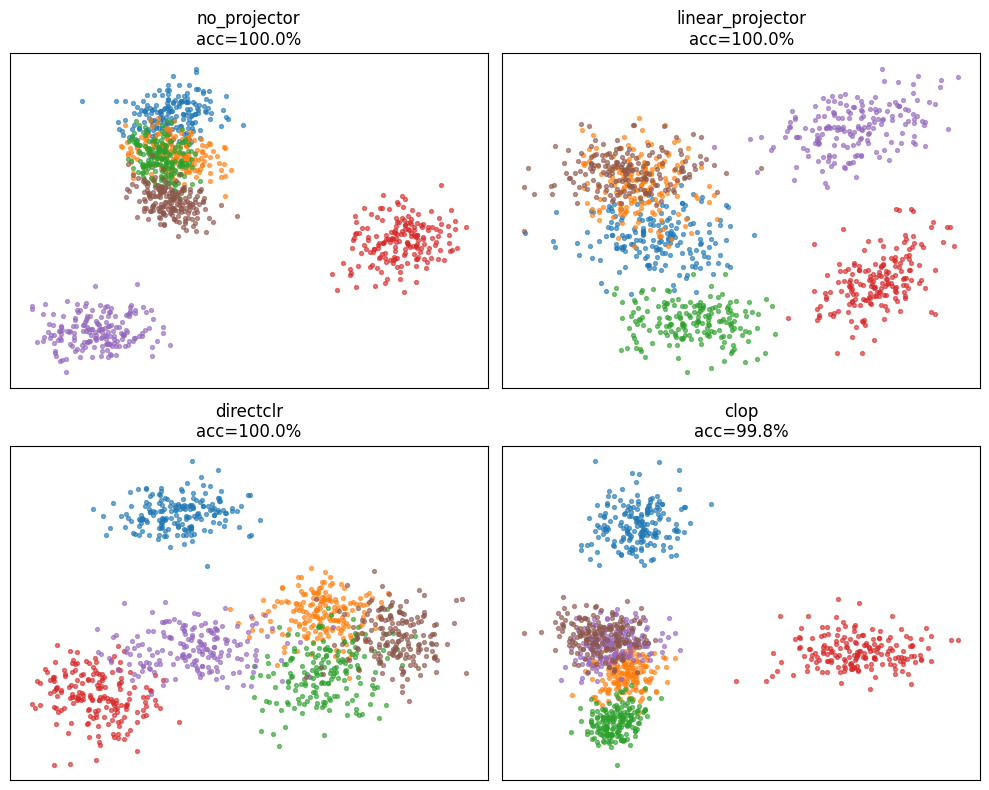

In [7]:
from sklearn.decomposition import PCA

plt.figure(figsize=(10, 8))
for idx, variant in enumerate(variants, start=1):
    model = results_ssl[variant]["model"]
    with torch.no_grad():
        R = model.representation(Xsyn.to(device)).cpu().numpy()
    pca = PCA(n_components=2)
    R2 = pca.fit_transform(R)

    plt.subplot(2, 2, idx)
    for c in np.unique(ysyn.numpy()):
        mask = (ysyn.numpy() == c)
        plt.scatter(R2[mask, 0], R2[mask, 1], s=8, alpha=0.6, label=f"class {c}")
    plt.title(f"{variant}\nacc={100*results_ssl[variant]['acc']:.1f}%")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

# CIFAR-10 with ResNet-50: SimCLR vs DirectCLR

In this section, we compare three contrastive learning variants using a ResNet-50 encoder:

- **SimCLR without projector**
- **SimCLR with a linear projector**
- **DirectCLR**

We follow the paper conceptually:

- the **encoder** is a ResNet-50 backbone,
- the **representation space** is the 2048-dimensional output of the backbone,
- the contrastive loss is applied either:
  - directly on the representation (`no_projector`),
  - after a linear projector (`linear_projector`),
  - or on a fixed subvector of the representation (`directclr`).

We evaluate:

- training loss,
- k-NN accuracy on the learned representations,
- covariance singular value spectrum of the representation space.

This is a CIFAR-10 adaptation of the paper setup, not a strict ImageNet reproduction.

In [1]:
import math
import random
from typing import Dict, Tuple

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50
from torch.utils.data import Dataset, DataLoader


from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import multiprocessing

In [2]:
NUM_CPUS = os.cpu_count()

os.environ["OMP_NUM_THREADS"] = str(NUM_CPUS)
os.environ["MKL_NUM_THREADS"] = str(NUM_CPUS)

torch.set_num_threads(NUM_CPUS)
torch.set_num_interop_threads(2)
torch.backends.mkldnn.enabled = True

print(NUM_CPUS, "Cpus")
print(torch.cuda.device_count(), "Gpus")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def set_seed(seed: int = 7):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(7)

40 Cpus
4 Gpus
Device: cuda


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
multi_gpu = torch.cuda.device_count() > 1
if multi_gpu:
    print("Multi-GPU activé sur", torch.cuda.device_count(), "GPU")

num_gpus = torch.cuda.device_count()

def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# =========================================================
# PARAMETERS (We can't afford as muchcomplexity as in CLOP as th representation here has a dimension of 2048)
# =========================================================
batch_size = 128
epochs = 30
temperature = 0.2

# Representation and DirectCLR dimensions
rep_dim = 2048
d0 = 512 #Projection dimension

# Optimizer
lr = 1e-3
weight_decay = 1e-6

num_workers = min(12, os.cpu_count())
pin_memory = (device == "cuda")

Device: cuda
Multi-GPU activé sur 4 GPU


In [4]:
def covariance_spectrum(Z: torch.Tensor) -> torch.Tensor:
    Z = Z - Z.mean(dim=0, keepdim=True)
    C = (Z.T @ Z) / max(1, Z.shape[0] - 1)
    return torch.linalg.svdvals(C).detach().cpu()

def effective_rank_from_svals(svals: torch.Tensor, eps: float = 1e-12) -> float:
    p = svals / (svals.sum() + eps)
    entropy = -(p * (p + eps).log()).sum().item()
    return float(np.exp(entropy))

def numerical_rank(svals: torch.Tensor, tol_ratio: float = 1e-3) -> int:
    smax = float(svals.max().item())
    return int((svals >= tol_ratio * smax).sum().item())

def plot_spectra(spectra: Dict[str, torch.Tensor], title: str, logy: bool = True):
    plt.figure(figsize=(7, 4))
    for name, svals in spectra.items():
        x = np.arange(1, len(svals) + 1)
        y = svals.numpy()
        plt.plot(x, y, linewidth=1.8, label=name)
    if logy:
        plt.yscale("log")
    plt.xlabel("Rank index")
    plt.ylabel("Singular value")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [5]:
def info_nce_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.2):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    z = torch.cat([z1, z2], dim=0)
    sim = (z @ z.T) / temperature

    n = z1.shape[0]
    mask = torch.eye(2 * n, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -1e9)

    targets = torch.arange(n, device=z.device)
    targets = torch.cat([targets + n, targets], dim=0)

    return F.cross_entropy(sim, targets)


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])


In [6]:
class CIFAR10TwoViews(Dataset):
    def __init__(self, root="./data", train=True, transform=None, download=True):
        self.base = torchvision.datasets.CIFAR10(
            root=root,
            train=train,
            transform=None,
            download=download
        )
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        x1 = self.transform(img)
        x2 = self.transform(img)
        return x1, x2, label

In [7]:
train_ssl_ds = CIFAR10TwoViews(
    root="./data",
    train=True,
    transform=train_transform,
    download=True
)

train_eval_ds = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    transform=test_transform,
    download=True
)

test_eval_ds = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    transform=test_transform,
    download=True
)

train_ssl_loader = DataLoader(
    train_ssl_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

train_eval_loader = DataLoader(
    train_eval_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

test_eval_loader = DataLoader(
    test_eval_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)
print("Train SSL size :", len(train_ssl_ds))
print("Train eval size:", len(train_eval_ds))
print("Test eval size :", len(test_eval_ds))

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train SSL size : 50000
Train eval size: 50000
Test eval size : 10000


In [8]:
class ResNet50Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = resnet50(weights=None)

        # CIFAR-friendly stem (since by default ResNet50 is desined for 224x224 imaes and 1000 classes)
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()
        # here we make sure fc doen't change our output as it will be used for contrastive learning (otherwise it will transform the data into logits and apply softmax by itself)
        backbone.fc = nn.Identity() #fully connected layer, in a typical ResNet50 fc = nn.Linear(2048, 1000) for 1000 classes

        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)   # (B, 2048) # beware 2048 is the representation's dimension not that of the embeddings

In [9]:
class TwoLayerProjector(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class SSLModel(nn.Module):
    def __init__(
        self,
        variant: str,
        rep_dim: int = 2048,
        proj_dim: int = 512,
        proj_hidden_dim: int = 2048,
        d0: int = 512,
    ):
        super().__init__()
        assert variant in {
            "no_projector",
            "linear_projector",
            "nonlinear_projector",
            "directclr",
        }

        self.variant = variant
        self.encoder = ResNet50Encoder()
        self.d0 = d0

        if variant == "linear_projector":
            self.projector = nn.Linear(rep_dim, proj_dim, bias=False)

        elif variant == "nonlinear_projector":
            self.projector = TwoLayerProjector(
                in_dim=rep_dim,
                hidden_dim=proj_hidden_dim,
                out_dim=proj_dim,
            )

        else:
            self.projector = None

    def representation(self, x):
        return self.encoder(x)

    def embedding(self, x):
        r = self.representation(x)

        if self.variant == "no_projector":
            return r
        elif self.variant == "linear_projector":
            return self.projector(r)
        elif self.variant == "nonlinear_projector":
            return self.projector(r)
        elif self.variant == "directclr":
            return r[:, :self.d0]

    def forward(self, x): # because with DataParallele, only forward is parallelised
        return self.embedding(x)

In [10]:
@torch.no_grad()
def extract_representations(model: SSLModel, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    reps = []
    labels = []

    for x, y in loader:
        x = x.to(device)
        #r = model.representation(x)
        if isinstance(model, nn.DataParallel):
            r = model.module.representation(x)
        else:
            r = model.representation(x)
        reps.append(r.cpu())
        labels.append(y)

    reps = torch.cat(reps, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()
    return reps, labels


def knn_eval(model: SSLModel, k: int = 5) -> float:
    X_train, y_train = extract_representations(model, train_eval_loader)
    X_test, y_test = extract_representations(model, test_eval_loader)

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    return accuracy_score(y_test, pred)

In [11]:
def train_encoder(variant: str):
    assert variant in {
        "no_projector",
        "linear_projector",
        "nonlinear_projector",
        "directclr",
    }

    set_seed(42)

    model = SSLModel(
        variant=variant,
        rep_dim=2048,
        proj_dim=512,
        proj_hidden_dim=2048,
        d0=512,
    )

    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for {variant}")
        model = nn.DataParallel(model, device_ids=[0, 1])

    model = model.to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    losses = []

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0

        for x1, x2, _ in train_ssl_loader:
            x1 = x1.to(device, non_blocking=True)
            x2 = x2.to(device, non_blocking=True)

            z1 = model(x1)
            z2 = model(x2)

            loss = info_nce_loss(z1, z2, temperature=temperature)

            opt.zero_grad()
            loss.backward()
            opt.step()

            running_loss += loss.item()
            losses.append(loss.item())

        print(f"{variant:20s} | Epoch {epoch+1:02d}/{epochs} | Loss {running_loss / len(train_ssl_loader):.4f}")

    return model, losses

In [13]:
# =========================================================
# RUN EXPERIMENTS
# =========================================================
results = []

all_outputs = {}

print("\n==============================")
print("=== SIMCLR / DIRECTCLR ===")
print("==============================")

for variant in ["no_projector", "linear_projector", "directclr"]:
    print(f"\n=== {variant.upper()} ===")
    enc, losses = train_encoder(variant=variant)
    acc = knn_eval(enc, k=5)

    with torch.no_grad():
        X_train_rep, _ = extract_representations(enc, train_eval_loader)
        R = torch.tensor(X_train_rep, dtype=torch.float32)
        svals = covariance_spectrum(R)

    out = {
        "model": enc,
        "losses": losses,
        "acc": acc,
        "rep_svals": svals,
        "rep_rank": numerical_rank(svals),
        "rep_erank": effective_rank_from_svals(svals),
    }
    all_outputs[variant] = out
    results.append((variant, acc, out["rep_rank"], out["rep_erank"]))

    print(f"{variant:16s} | Accuracy: {acc*100:.2f}% | Rank: {out['rep_rank']} | Effective rank: {out['rep_erank']:.2f}")


=== SIMCLR / DIRECTCLR ===

=== NO_PROJECTOR ===
Using 4 GPUs for no_projector
no_projector         | Epoch 01/30 | Loss 3.6685
no_projector         | Epoch 02/30 | Loss 2.8764
no_projector         | Epoch 03/30 | Loss 2.5400
no_projector         | Epoch 04/30 | Loss 2.3479
no_projector         | Epoch 05/30 | Loss 2.2286
no_projector         | Epoch 06/30 | Loss 2.1464
no_projector         | Epoch 07/30 | Loss 2.0822
no_projector         | Epoch 08/30 | Loss 2.0407
no_projector         | Epoch 09/30 | Loss 1.9960
no_projector         | Epoch 10/30 | Loss 1.9591
no_projector         | Epoch 11/30 | Loss 1.9183
no_projector         | Epoch 12/30 | Loss 1.9018
no_projector         | Epoch 13/30 | Loss 1.8771
no_projector         | Epoch 14/30 | Loss 1.8548
no_projector         | Epoch 15/30 | Loss 1.8249
no_projector         | Epoch 16/30 | Loss 1.8121
no_projector         | Epoch 17/30 | Loss 1.7970
no_projector         | Epoch 18/30 | Loss 1.7802
no_projector         | Epoch 19/30 | L

In [15]:
print(acc) 

0.7096


## Reading guide for the results

What you should generally expect:

- **Experiment 1:** stronger augmentation pushes the encoder/embedding spectrum toward lower rank.
- **Experiment 2:** larger depth tends to worsen the spectral collapse, even when augmentation is weak.
- **Experiment 3:** the alignment error should decrease during training.
- **Experiment 4:**  
  - **no projector** often has the worst representation rank;  
  - **linear projector** usually protects the representation better;  
  - **DirectCLR-style** often recovers part of this benefit without a trainable projector;  
  - **CLOP** can be added as an extra contrastive regularizer when labeled points are available.

Because these are small synthetic experiments, absolute accuracies can vary a lot with the seed.  
The important signal is the **geometry**:
spectra, ranks, alignment, and the relative trend between methods.

## Main takeaways

This notebook provides a compact experimental counterpart to the theory:

1. **Contrastive learning can suffer from dimensional collapse.**
2. This collapse can come from **strong augmentation**.
3. It can also come from **implicit regularization in deep models**.
4. The **projector** is not just a convenience: it changes where collapse happens.
5. A **DirectCLR-style loss on a fixed subvector** is a simple way to protect the representation space.
6. When labeled data exists, **CLOP** can be added to encourage subspace separation with orthonormal prototypes.

That makes this notebook a good starting point for:
- your IRL project,
- comparisons between InfoNCE / DirectCLR / CLOP,
- and future experiments on real datasets once you have cluster access.